# Untouched Final Holdout

## Crypto Alpha Across Horizons

This notebook presents the project's confirmatory test.

Before 2025+ was opened, the research had already frozen:

- three exact continuation implementations — **ECON, BAL, SHARP**;
- the 20-bps primary cost assumption;
- the survival rule;
- the dependence-aware IC convention;
- the no-retuning / no-combination protocol.

The original Step-12 engine first reproduced the pre-2025 finalist metrics and then opened the **2025-01-01 through 2026-08-01 exclusive** holdout once.

### Public-package execution design

The canonical Step-12 engine generated small frozen research artifacts after the one-time holdout evaluation. This public notebook uses those artifacts to make the confirmatory record transparent and reproducible without re-opening the holdout or re-downloading exchange data:

1. verify the frozen protocol file;
2. verify that the saved pre-2025 reproduction gate passed;
3. load the exact saved holdout return and IC series;
4. independently recompute the principal holdout statistics from those series;
5. compare the recomputed values against the authoritative Step-12 metric table;
6. reproduce degradation, correlations, cumulative performance, and drawdowns.

The raw holdout-construction engine belongs in the repository's shared research code. This notebook is the clean confirmatory report layer.

In [1]:
from pathlib import Path
import os
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display


def locate_project_root():
    env_root = os.getenv("CRYPTO_ALPHA_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "data").is_dir():
            return candidate

    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "crypto-alpha-research",
        cwd.parent / "crypto-alpha-research",
    ]
    for candidate in candidates:
        if (candidate / "data").is_dir() and (
            (candidate / "notebooks").is_dir()
            or (candidate / "public_notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Set CRYPTO_ALPHA_ROOT "
        "to the crypto-alpha-research folder."
    )


PROJECT_ROOT = locate_project_root()
RESEARCH_DIR = PROJECT_ROOT / "data" / "research"

HOLDOUT_START = pd.Timestamp("2025-01-01 00:00:00", tz="UTC")
HOLDOUT_END = pd.Timestamp("2026-08-01 00:00:00", tz="UTC")
PRIMARY_COST_BPS = 20.0

FINALISTS = {
    "ECON": {
        "mapping": "continuous_rank",
        "formation": "2w",
        "holding": "6w",
        "holding_hours": 6 * 7 * 24,
        "cadence": "24h",
        "cadence_hours": 24,
    },
    "BAL": {
        "mapping": "equal_weight_terciles",
        "formation": "3d",
        "holding": "8w",
        "holding_hours": 8 * 7 * 24,
        "cadence": "48h",
        "cadence_hours": 48,
    },
    "SHARP": {
        "mapping": "equal_weight_terciles",
        "formation": "1d",
        "holding": "8w",
        "holding_hours": 8 * 7 * 24,
        "cadence": "8h",
        "cadence_hours": 8,
    },
}

print("Project root:", PROJECT_ROOT)
print("Research cache:", RESEARCH_DIR)
print("Holdout:", HOLDOUT_START, "to", HOLDOUT_END, "exclusive")

Project root: /Users/owensimon/crypto-alpha-research
Research cache: /Users/owensimon/crypto-alpha-research/data/research
Holdout: 2025-01-01 00:00:00+00:00 to 2026-08-01 00:00:00+00:00 exclusive


## 1. Frozen protocol and pre-2025 reproduction gate

The final-test protocol is not reconstructed from memory. It is read from the JSON file that was frozen before the holdout was evaluated.

The primary survival condition was:

- mean continuation IC > 0;
- gross annualized mean return > 0;
- break-even execution cost ≥ 20 bps.

There was **no Sharpe threshold** and **no HAC-significance threshold** in the survival rule.

Before opening 2025+, all six finalist/window pre-2025 reproductions had to match the frozen Step-11 evidence within tolerance.

In [2]:
protocol_path = RESEARCH_DIR / "step12_frozen_holdout_protocol.json"
repro_path = RESEARCH_DIR / "step12_pre2025_finalist_reproduction_comparison.csv"

if not protocol_path.exists():
    raise FileNotFoundError(protocol_path)
if not repro_path.exists():
    raise FileNotFoundError(repro_path)

with open(protocol_path, "r", encoding="utf-8") as f:
    protocol = json.load(f)

assert protocol["holdout_start"] == str(HOLDOUT_START)
assert protocol["holdout_end_exclusive"] == str(HOLDOUT_END)
assert float(protocol["primary_cost_bps"]) == PRIMARY_COST_BPS
assert protocol["combined_portfolio"] is False

rule = protocol["primary_survival_rule"]
assert float(rule["mean_continuation_ic_gt"]) == 0.0
assert float(rule["gross_ann_return_gt"]) == 0.0
assert float(rule["break_even_cost_bps_ge"]) == 20.0

for finalist, spec in FINALISTS.items():
    frozen = protocol["finalists"][finalist]
    assert frozen["portfolio_mapping"] == spec["mapping"]
    assert frozen["formation_horizon"] == spec["formation"]
    assert frozen["holding_horizon"] == spec["holding"]
    assert frozen["decision_cadence"] == spec["cadence"]

repro = pd.read_csv(repro_path)
assert len(repro) == 6
assert set(repro["finalist"]) == set(FINALISTS)
assert set(repro["window"]) == {"development", "evaluation"}

pass_cols = [c for c in repro.columns if c.endswith("_pass")]
assert pass_cols, "No reproduction pass columns found."
assert repro[pass_cols].all(axis=None)
assert repro["frozen_gate_pass"].all()

print("Frozen Step-12 protocol: PASS")
print("Pre-2025 finalist reproduction gate: PASS")
print("Rows checked:", len(repro))
display(
    repro[
        [
            "finalist", "window",
            "mean_price_ic_abs_diff",
            "gross_sharpe_ann_abs_diff",
            "break_even_cost_bps_abs_diff",
            "net20_sharpe_ann_abs_diff",
            "frozen_gate_pass",
        ]
    ].round(10)
)

Frozen Step-12 protocol: PASS
Pre-2025 finalist reproduction gate: PASS
Rows checked: 6


,finalist,window,mean_price_ic_abs_diff,gross_sharpe_ann_abs_diff,break_even_cost_bps_abs_diff,net20_sharpe_ann_abs_diff,frozen_gate_pass
0,BAL,development,3.723000e-07,4.600000e-07,1.030000e-07,3.867000e-07,True
1,BAL,evaluation,2.996000e-07,4.161000e-07,1.886000e-07,4.815000e-07,True
2,ECON,development,1.614000e-07,2.150000e-07,3.220000e-07,1.122000e-07,True
3,ECON,evaluation,1.886000e-07,4.452000e-07,4.700000e-09,3.534000e-07,True
4,SHARP,development,3.467000e-07,3.091000e-07,4.873000e-07,2.388000e-07,True
5,SHARP,evaluation,3.367000e-07,4.836000e-07,3.766000e-07,9.340000e-08,True


## 2. Load the frozen holdout record

The canonical Step-12 run saved:

- the authoritative finalist metric table;
- exact native-cadence gross/net-20 return and turnover series;
- timestamp-level IC series;
- common non-overlapping 48h gross returns;
- the pre-2025-to-holdout degradation table.

The detailed return and IC series allow the main statistics to be recomputed independently rather than merely displayed from a summary CSV.

In [3]:
metrics_path = RESEARCH_DIR / "step12_final_holdout_metrics.csv"
returns_path = RESEARCH_DIR / "step12_finalist_return_series.parquet"
ic_path = RESEARCH_DIR / "step12_finalist_ic_series.parquet"
common48_path = RESEARCH_DIR / "step12_finalist_common_48h_gross_returns.parquet"
corr_path = RESEARCH_DIR / "step12_finalist_gross_return_correlations_48h.csv"
degradation_path = RESEARCH_DIR / "step12_final_holdout_degradation.csv"

for path in [
    metrics_path, returns_path, ic_path,
    common48_path, corr_path, degradation_path,
]:
    if not path.exists():
        raise FileNotFoundError(path)

frozen_metrics = pd.read_csv(metrics_path)
returns_long = pd.read_parquet(returns_path)
ic_long = pd.read_parquet(ic_path)
common48 = pd.read_parquet(common48_path)
frozen_corr = pd.read_csv(corr_path, index_col=0)
degradation = pd.read_csv(degradation_path)

for frame in [returns_long, ic_long]:
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True)

assert set(frozen_metrics["finalist"]) == set(FINALISTS)
assert set(returns_long["finalist"]) == set(FINALISTS)
assert set(ic_long["finalist"]) == set(FINALISTS)

assert returns_long["timestamp"].min() >= HOLDOUT_START
assert returns_long["timestamp"].max() <= HOLDOUT_END
assert ic_long["timestamp"].min() >= HOLDOUT_START
assert ic_long["timestamp"].max() < HOLDOUT_END

print("Frozen holdout artifacts loaded: PASS")
print("Return-series rows:", len(returns_long))
print("IC-series rows:", len(ic_long))
print("Common 48h blocks:", len(common48))

Frozen holdout artifacts loaded: PASS
Return-series rows: 2599
IC-series rows: 2361
Common 48h blocks: 288


## 3. Independent series-level reproduction

Annualization follows each finalist's native decision cadence:

\[
\text{periods/year} = \frac{365.25 \times 24}{\text{cadence hours}}.
\]

Turnover is the full-L1 target-to-target change already stored in the exact Step-12 portfolio path. Net-20 return is therefore checked again from:

\[
r^{net20}_t = r^{gross}_t - 0.002 \cdot TO_t.
\]

IC inference uses a HAC mean t-stat with overlap-aware lag:

\[
\lceil \text{holding}/\text{cadence} \rceil - 1.
\]

In [4]:
def annualized_sharpe(x, periods_per_year):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    sigma = x.std(ddof=1)
    if not np.isfinite(sigma) or sigma <= 0:
        return np.nan
    return float(x.mean() / sigma * np.sqrt(periods_per_year))


def annualized_mean_return(x, periods_per_year):
    x = pd.Series(x).dropna().astype(float)
    return float(x.mean() * periods_per_year) if len(x) else np.nan


def annualized_volatility(x, periods_per_year):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    return float(x.std(ddof=1) * np.sqrt(periods_per_year))


def hac_mean_tstat(x, maxlags):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 20:
        return np.nan
    maxlags = int(min(maxlags, len(x) - 1))
    X = np.ones((len(x), 1), dtype=float)
    fit = sm.OLS(x.to_numpy(), X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags},
    )
    return float(fit.tvalues[0])


recomputed_rows = []

for finalist, spec in FINALISTS.items():
    pnl = (
        returns_long.loc[returns_long["finalist"].eq(finalist)]
        .sort_values("timestamp")
        .set_index("timestamp")
    )
    ic = (
        ic_long.loc[ic_long["finalist"].eq(finalist)]
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    # Exact net-cost identity.
    reconstructed_net20 = (
        pnl["gross_return"] - PRIMARY_COST_BPS * 1e-4 * pnl["turnover"]
    )
    max_net_diff = float(
        (reconstructed_net20 - pnl["net20_return"]).abs().max()
    )
    assert max_net_diff < 1e-12

    ppy = 365.25 * 24.0 / spec["cadence_hours"]
    overlap_lags = max(
        0,
        int(math.ceil(spec["holding_hours"] / spec["cadence_hours"]) - 1),
    )

    gross_wealth = (1.0 + pnl["gross_return"]).cumprod()
    net20_wealth = (1.0 + pnl["net20_return"]).cumprod()
    gross_dd = gross_wealth / gross_wealth.cummax() - 1.0
    net20_dd = net20_wealth / net20_wealth.cummax() - 1.0

    gross = pnl["gross_return"]
    net20 = pnl["net20_return"]
    turnover = pnl["turnover"]

    recomputed_rows.append(
        {
            "finalist": finalist,
            "mean_price_ic": float(ic["price_ic"].mean()),
            "price_ic_hac_t": hac_mean_tstat(ic["price_ic"], overlap_lags),
            "n_price_ic": int(ic["price_ic"].notna().sum()),
            "ic_hac_lags": overlap_lags,
            "gross_ann_return": annualized_mean_return(gross, ppy),
            "gross_ann_vol": annualized_volatility(gross, ppy),
            "gross_sharpe_ann": annualized_sharpe(gross, ppy),
            "net20_ann_return": annualized_mean_return(net20, ppy),
            "net20_sharpe_ann": annualized_sharpe(net20, ppy),
            "mean_turnover_per_decision": float(turnover.mean()),
            "annualized_turnover": float(turnover.mean() * ppy),
            "total_turnover": float(turnover.sum()),
            "break_even_cost_bps": float(gross.sum() / turnover.sum() * 1e4),
            "gross_cumulative_return": float(gross_wealth.iloc[-1] - 1.0),
            "net20_cumulative_return": float(net20_wealth.iloc[-1] - 1.0),
            "gross_max_drawdown": float(gross_dd.min()),
            "net20_max_drawdown": float(net20_dd.min()),
            "max_net20_identity_diff": max_net_diff,
        }
    )

recomputed = pd.DataFrame(recomputed_rows).sort_values("finalist").reset_index(drop=True)
frozen = frozen_metrics.sort_values("finalist").reset_index(drop=True)

compare_metrics = [
    "mean_price_ic",
    "price_ic_hac_t",
    "gross_ann_return",
    "gross_ann_vol",
    "gross_sharpe_ann",
    "net20_ann_return",
    "net20_sharpe_ann",
    "annualized_turnover",
    "total_turnover",
    "break_even_cost_bps",
    "gross_cumulative_return",
    "net20_cumulative_return",
    "gross_max_drawdown",
    "net20_max_drawdown",
]

audit_rows = []
for metric in compare_metrics:
    diff = (
        recomputed[metric].astype(float)
        - frozen[metric].astype(float)
    ).abs()
    audit_rows.append(
        {
            "metric": metric,
            "max_abs_diff": float(diff.max()),
        }
    )

audit = pd.DataFrame(audit_rows)
assert audit["max_abs_diff"].max() < 1e-9

print("Detailed holdout-series reproduction vs authoritative Step-12 table: PASS")
display(audit)

Detailed holdout-series reproduction vs authoritative Step-12 table: PASS


,metric,max_abs_diff
0,mean_price_ic,8.326673e-17
1,price_ic_hac_t,0.000000e+00
2,gross_ann_return,8.326673e-17
3,gross_ann_vol,8.326673e-17
4,gross_sharpe_ann,2.220446e-16
5,net20_ann_return,8.326673e-17
6,net20_sharpe_ann,8.326673e-17
7,annualized_turnover,0.000000e+00
8,total_turnover,1.421085e-14
9,break_even_cost_bps,7.105427e-15


## 4. Untouched holdout result

The predeclared survival test is now applied exactly as frozen. It is a deliberately modest criterion: correct continuation direction, positive gross economics, and enough realized return per unit turnover to cover the primary 20-bps cost assumption.

The three finalists are **not** treated as three independent alphas. They are alternative implementations of one continuation factor.

In [5]:
report = recomputed[
    [
        "finalist",
        "mean_price_ic",
        "price_ic_hac_t",
        "gross_ann_return",
        "gross_sharpe_ann",
        "net20_ann_return",
        "net20_sharpe_ann",
        "break_even_cost_bps",
        "annualized_turnover",
        "gross_cumulative_return",
        "net20_cumulative_return",
        "gross_max_drawdown",
        "net20_max_drawdown",
    ]
].copy()

report["survives_direction"] = report["mean_price_ic"] > 0.0
report["survives_gross_economics"] = report["gross_ann_return"] > 0.0
report["survives_20bps_break_even"] = report["break_even_cost_bps"] >= PRIMARY_COST_BPS
report["primary_survival_pass"] = (
    report["survives_direction"]
    & report["survives_gross_economics"]
    & report["survives_20bps_break_even"]
)

assert report["primary_survival_pass"].all()

# Headline-result regression checks.
headline = report.set_index("finalist")
assert np.isclose(headline.loc["ECON", "gross_sharpe_ann"], 0.334, atol=0.002)
assert np.isclose(headline.loc["BAL", "gross_sharpe_ann"], 0.788, atol=0.002)
assert np.isclose(headline.loc["SHARP", "gross_sharpe_ann"], 1.132, atol=0.002)

assert np.isclose(headline.loc["ECON", "break_even_cost_bps"], 28.50, atol=0.02)
assert np.isclose(headline.loc["BAL", "break_even_cost_bps"], 42.01, atol=0.02)
assert np.isclose(headline.loc["SHARP", "break_even_cost_bps"], 31.72, atol=0.02)

display(report.round(6))

print("PRIMARY HOLDOUT RESULT: 3 / 3 frozen continuation archetypes PASS")
print("No parameter rescue, post-holdout combination, or winner selection is performed.")

,finalist,mean_price_ic,price_ic_hac_t,gross_ann_return,gross_sharpe_ann,net20_ann_return,net20_sharpe_ann,break_even_cost_bps,annualized_turnover,gross_cumulative_return,net20_cumulative_return,gross_max_drawdown,net20_max_drawdown,survives_direction,survives_gross_economics,survives_20bps_break_even,primary_survival_pass
0,BAL,0.046582,2.269823,0.160402,0.788064,0.084034,0.412757,42.007634,38.184114,0.247299,0.105357,-0.110007,-0.127902,True,True,True,True
1,ECON,0.048372,1.211216,0.074949,0.333832,0.022344,0.099474,28.495171,26.302446,0.081765,-0.004681,-0.168859,-0.185277,True,True,True,True
2,SHARP,0.036762,2.591153,0.230588,1.132380,0.085216,0.418355,31.723803,72.686035,0.393248,0.107229,-0.139526,-0.165662,True,True,True,True


PRIMARY HOLDOUT RESULT: 3 / 3 frozen continuation archetypes PASS
No parameter rescue, post-holdout combination, or winner selection is performed.


## 5. Degradation versus the pre-2025 evaluation

Passing the final test does **not** imply full-strength replication.

The final holdout preserves the continuation direction, but risk-adjusted and post-cost economics are materially weaker than the 2023–2024 internal evaluation. That degradation is part of the result, not something to tune away.

In [6]:
selected_degradation_metrics = [
    "mean_price_ic",
    "gross_sharpe_ann",
    "net20_sharpe_ann",
    "break_even_cost_bps",
]

deg = degradation.loc[
    degradation["metric"].isin(selected_degradation_metrics)
].copy()

deg_table = (
    deg.pivot(
        index="finalist",
        columns="metric",
        values=[
            "evaluation_2023_2024",
            "holdout_2025_2026_07",
            "retention_vs_evaluation_pct",
        ],
    )
)

display(deg_table.round(4))

print("Interpretation: continuation survives, but economic strength degrades materially.")

evaluation_2023_2024                                                  \
metric    break_even_cost_bps gross_sharpe_ann mean_price_ic net20_sharpe_ann   
finalist                                                                        
BAL                   72.9912           1.4166        0.0435           1.0287   
ECON                  78.9695           0.9152        0.0539           0.6835   
SHARP                 60.9128           1.9392        0.0429           1.3026   

         holdout_2025_2026_07                                                  \
metric    break_even_cost_bps gross_sharpe_ann mean_price_ic net20_sharpe_ann   
finalist                                                                        
BAL                   42.0076           0.7881        0.0466           0.4128   
ECON                  28.4952           0.3338        0.0484           0.0995   
SHARP                 31.7238           1.1324        0.0368           0.4184   

         retention_vs_evaluation_pct                                 \
metric           break_even_cost_bps gross_sharpe_ann mean_price_ic   
finalist                                                              
BAL                          57.5516          55.6320      107.0811   
ECON                         36.0838          36.4748       89.7104   
SHARP                        52.0807          58.3946       85.6206   

                           
metric   net20_sharpe_ann  
finalist                   
BAL               40.1230  
ECON              14.5541  
SHARP             32.1166

Interpretation: continuation survives, but economic strength degrades materially.


## 6. Cumulative performance and drawdowns

These path statistics are descriptive. They are not additional survival rules.

The distinction between gross and net-20 performance is especially important: transaction costs materially reduce the realized economic strength of all three implementations.

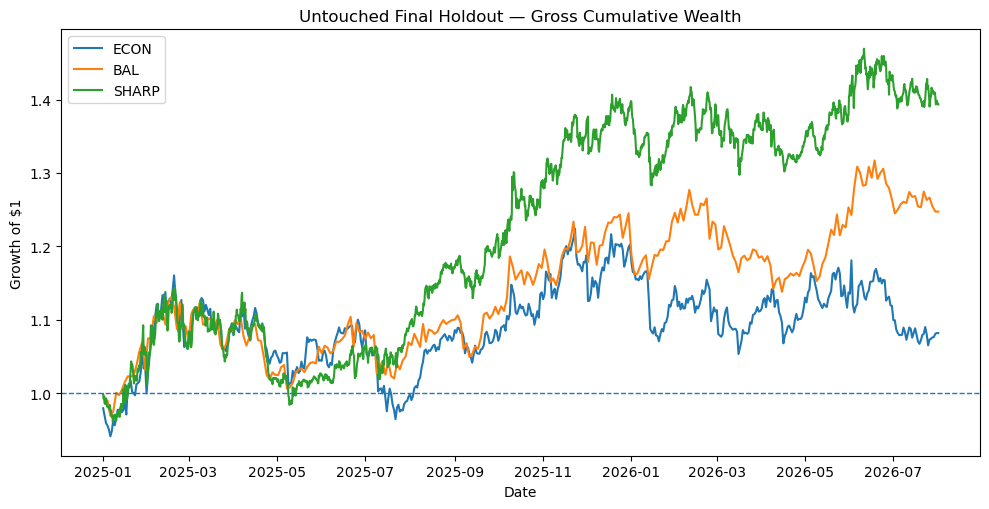

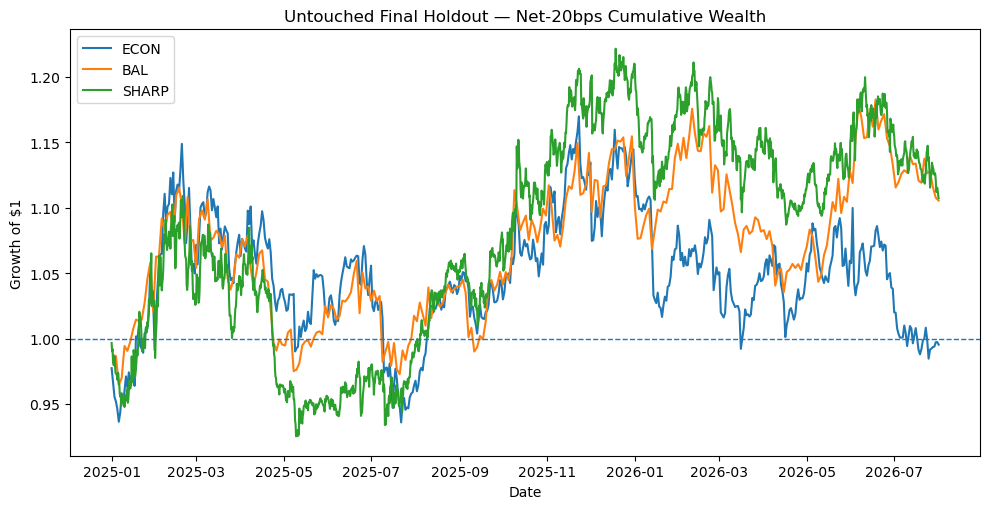

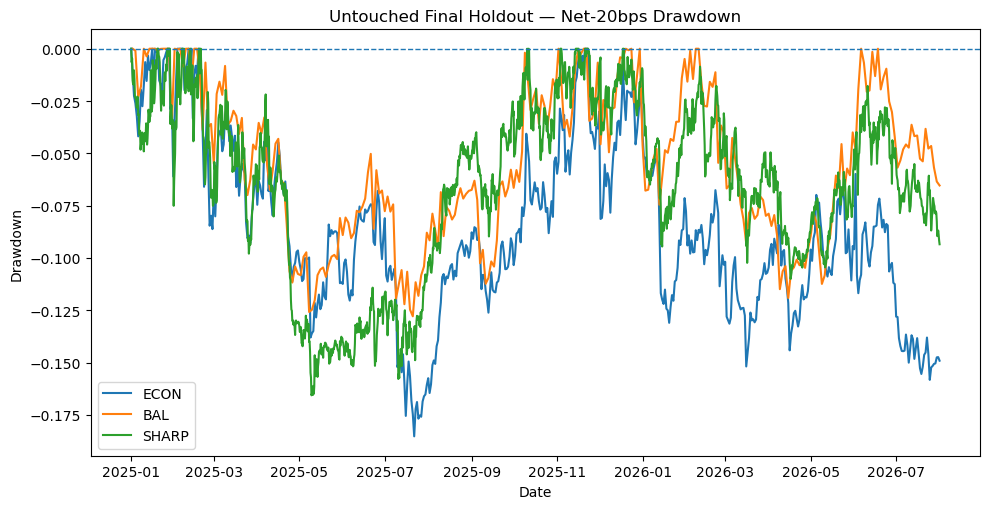

In [7]:
pnl_by_finalist = {
    finalist: (
        returns_long.loc[returns_long["finalist"].eq(finalist)]
        .sort_values("timestamp")
        .set_index("timestamp")
    )
    for finalist in FINALISTS
}

fig, ax = plt.subplots(figsize=(10, 5.2))
for finalist, pnl in pnl_by_finalist.items():
    wealth = (1.0 + pnl["gross_return"]).cumprod()
    ax.plot(wealth.index, wealth, label=finalist)
ax.axhline(1.0, linestyle="--", linewidth=1.0)
ax.set_title("Untouched Final Holdout — Gross Cumulative Wealth")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.2))
for finalist, pnl in pnl_by_finalist.items():
    wealth = (1.0 + pnl["net20_return"]).cumprod()
    ax.plot(wealth.index, wealth, label=finalist)
ax.axhline(1.0, linestyle="--", linewidth=1.0)
ax.set_title("Untouched Final Holdout — Net-20bps Cumulative Wealth")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.2))
for finalist, pnl in pnl_by_finalist.items():
    wealth = (1.0 + pnl["net20_return"]).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    ax.plot(drawdown.index, drawdown, label=finalist)
ax.axhline(0.0, linestyle="--", linewidth=1.0)
ax.set_title("Untouched Final Holdout — Net-20bps Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Common-clock correlation

Because the three implementations operate at different native cadences, their return correlation is evaluated on a common non-overlapping **48h clock** using compounded gross returns.

High correlation is expected if the three archetypes are different implementations of the same continuation phenomenon rather than independent alpha sources.

In [8]:
recomputed_corr = common48.corr()

# Align labels in case CSV/parquet loading produced different index metadata.
frozen_corr = frozen_corr.astype(float)
frozen_corr = frozen_corr.reindex(index=recomputed_corr.index, columns=recomputed_corr.columns)

corr_diff = (recomputed_corr - frozen_corr).abs().to_numpy()
assert np.nanmax(corr_diff) < 1e-12

display(recomputed_corr.round(3))

assert recomputed_corr.loc["ECON", "BAL"] > 0.80
assert recomputed_corr.loc["ECON", "SHARP"] > 0.80
assert recomputed_corr.loc["BAL", "SHARP"] > 0.90

print("Common-48h correlation reproduction: PASS")
print("Interpretation: three implementations of one continuation factor, not three independent alphas.")

,ECON,BAL,SHARP
ECON,1.000,0.828,0.855
BAL,0.828,1.000,0.918
SHARP,0.855,0.918,1.000


Common-48h correlation reproduction: PASS
Interpretation: three implementations of one continuation factor, not three independent alphas.


## 8. Confirmatory conclusion

All three exact pre-frozen continuation implementations pass the untouched final holdout rule:

- **ECON** survives, but its post-cost economics weaken sharply;
- **BAL** retains the largest realized execution-cost cushion;
- **SHARP** retains the strongest gross risk-adjusted performance.

The correct conclusion is **3/3 implementation-level survival of one continuation architecture**, not three independent alphas and not a post-holdout declaration that one implementation is the sole winner.

The final test also documents substantial degradation versus pre-2025 evidence. That weaker replication is preserved.

No finalist parameter is changed after the holdout is viewed. No combined portfolio is fit. No 2025+ result is used to redesign the signal.

The next notebook characterizes the already-frozen result through cost sensitivity, downside risk, temporal breadth, market exposure, and implementation concentration.